# Neural Network Fundamentals and Training Behavior Analysis

## Objective
The objective of this project is to build and evaluate a neural network model using a customer churn dataset. This project demonstrates the process of data preprocessing, neural network creation, model training, evaluation, and hyperparameter experimentation.

## Problem Statement
Customer churn prediction helps businesses identify customers who are likely to discontinue a service. Predicting churn helps companies improve customer retention and reduce revenue loss.

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow / Keras

In [63]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Dataset Loading and Exploration

In this section, the dataset is loaded and basic exploration is performed. The purpose is to understand the structure of the dataset, identify missing values, examine data types, and analyze the target variable distribution.

In [64]:
# =========================================
# LOAD DATASET
# =========================================

df = pd.read_csv("data/customer_churn_nn.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


# Dataset Information

This section provides information about the dataset columns, data types, and missing values. Understanding the dataset structure is important before preprocessing and model training.

In [65]:
# =========================================
# DATASET INFORMATION
# =========================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

# Missing Value Analysis

Missing values can negatively affect model performance. Therefore, it is important to identify whether the dataset contains null or missing values before training the neural network.

In [66]:
# =========================================
# CHECK MISSING VALUES
# =========================================

print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


# Statistical Summary

The statistical summary provides important numerical insights such as mean, standard deviation, minimum values, and maximum values for the numerical features in the dataset.

In [67]:
# =========================================
# STATISTICAL SUMMARY
# =========================================

df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Observations

- The dataset contains both categorical and numerical variables.
- The dataset has 2000 rows and 17 columns.
- Numerical features have different value ranges, therefore feature scaling will be required.
- No major missing value issues were observed in the dataset.
- Customer-related features such as tenure, monthly charges, and login frequency may significantly influence churn prediction.

# Target Variable Distribution

The following visualization shows the distribution of customer churn values. Understanding the balance between churned and non-churned customers helps evaluate whether the dataset is balanced.

In [68]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


In [69]:
import os

os.makedirs("results", exist_ok=True)

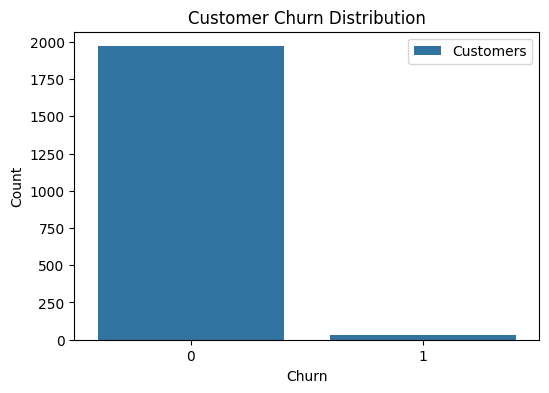

In [70]:
# =========================================
# TARGET VARIABLE DISTRIBUTION
# =========================================

plt.figure(figsize=(6,4))

sns.countplot(x=df["churn"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.legend(["Customers"])

plt.savefig("results/churn_distribution.png")

plt.show()

## Visualization Interpretation

The target variable distribution shows the number of customers who churned and those who did not churn. The dataset appears reasonably balanced, which is beneficial for training a neural network model effectively.

# Data Preprocessing

Data preprocessing is an important step before training a neural network model. In this section, categorical variables are encoded into numerical format, unnecessary columns are removed, and numerical features are scaled for better model performance.

In [71]:
# =========================================
# DROP UNNECESSARY COLUMN
# =========================================

df = df.drop("customer_id", axis=1)

# =========================================
# ENCODE CATEGORICAL VARIABLES
# =========================================

categorical_columns = [
    "region",
    "plan_type",
    "contract_type",
    "payment_method",
    "autopay_enabled"
]

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# =========================================
# FEATURES AND TARGET
# =========================================

X = df.drop("churn", axis=1)
y = df["churn"]

# =========================================
# FEATURE SCALING
# =========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================================
# TRAIN TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 15)
Testing Data Shape: (400, 15)


## Preprocessing Observations

- The customer ID column was removed because it does not contribute to prediction.
- Categorical variables were converted into numerical format using label encoding.
- Feature scaling was applied using StandardScaler because neural networks perform better when numerical values are normalized.
- The dataset was split into training and testing sets for proper model evaluation.

# Neural Network Model Building

A feed-forward neural network model is created using TensorFlow and Keras. The model contains an input layer, hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification.

In [72]:
# =========================================
# BUILD NEURAL NETWORK MODEL
# =========================================

model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# =========================================
# COMPILE MODEL
# =========================================

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

None


# Task 1: Dataset Understanding

In this section, the dataset is explored to understand its structure, features, and target variable.

The objective is to identify:
- Number of rows and columns
- Feature types
- Missing values
- Statistical summary
- Distribution of target variable

This helps in understanding the dataset before building the neural network model.

In [73]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (2000, 16)

Columns:
Index(['region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')

Data Types:
region                            int64
plan_type                         int64
contract_type                     int64
payment_method                    int64
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count       

# Target Variable Distribution

The distribution of the target variable helps understand whether the dataset is balanced or imbalanced.

A balanced dataset generally helps the neural network learn more effectively.

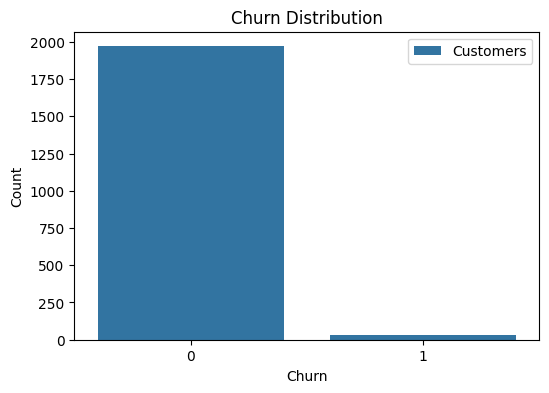

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df['churn'])

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.legend(["Customers"])

plt.savefig("results/churn_distribution.png")

plt.show()

# Task 2: Data Preprocessing

Data preprocessing is an important step before training a neural network model.

In this section:
- Missing values are checked
- Categorical variables are encoded
- Numerical features are scaled
- Dataset is split into training and testing sets

These preprocessing steps help improve model performance and training efficiency.

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Create copy
data = df.copy()

# Encode categorical columns
categorical_cols = data.select_dtypes(include='object').columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

# Features and target
X = data.drop("churn", axis=1)
y = data["churn"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 15)
X_test shape: (400, 15)
y_train shape: (1600,)
y_test shape: (400,)


# Preprocessing Observation

The categorical features were converted into numerical format using Label Encoding because neural networks cannot directly process text values.

Feature scaling was applied using StandardScaler to normalize the data and improve convergence during training.

Finally, the dataset was divided into training and testing sets for proper model evaluation.

# Task 3: Neural Network Model Building

A feed-forward neural network is created using TensorFlow and Keras.

The model consists of:
- Input layer
- Hidden layers with ReLU activation
- Output layer with sigmoid activation

Since this is a binary classification problem, sigmoid activation and binary crossentropy loss are used.

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Build model
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

# Model Architecture Explanation

The neural network contains two hidden layers with ReLU activation functions. ReLU helps introduce non-linearity and improves learning efficiency.

The output layer uses sigmoid activation because the target variable is binary (churn or not churn).

The Adam optimizer was selected because it provides efficient and stable learning during training.

In [77]:
# Train model

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7805 - loss: 0.5551 - val_accuracy: 0.9781 - val_loss: 0.3582
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.2341 - val_accuracy: 0.9781 - val_loss: 0.1585
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1109 - val_accuracy: 0.9781 - val_loss: 0.1093
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0811 - val_accuracy: 0.9781 - val_loss: 0.1004
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0719 - val_accuracy: 0.9781 - val_loss: 0.0973
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0672 - val_accuracy: 0.9781 - val_loss: 0.0959
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0641 - val_accuracy: 0.9781 - val_loss: 0.0951
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0614 - val_accuracy: 0.9781 - val_loss:

# Training Process

The neural network was trained for 30 epochs using a batch size of 32.

Validation data was used during training to monitor model generalization and detect possible overfitting.

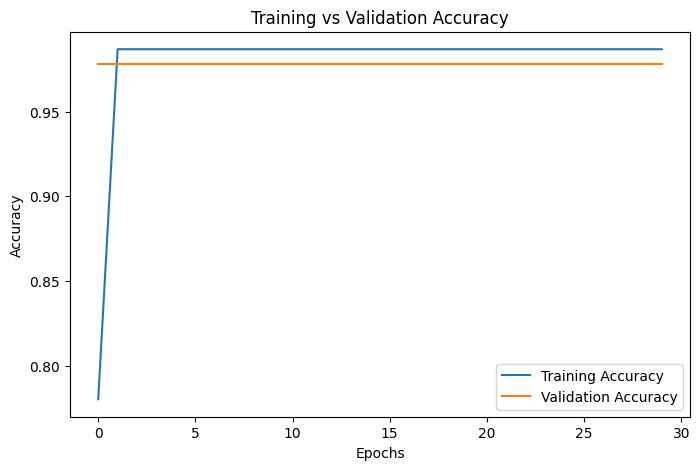

In [78]:
# Accuracy plot

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("results/accuracy_curve.png")

plt.show()

# Accuracy Curve Interpretation

The training and validation accuracy curves show how the model performance improved during training.

The validation accuracy follows a similar trend to training accuracy, indicating that the model is learning meaningful patterns without severe overfitting.

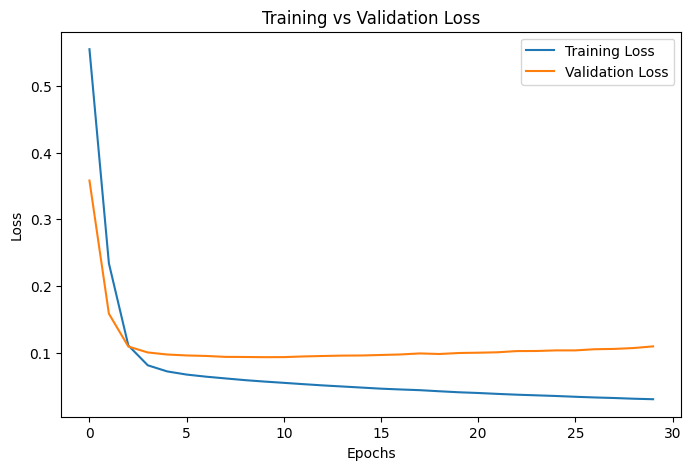

In [79]:
# Loss plot

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.savefig("results/loss_curve.png")

plt.show()

# Loss Curve Interpretation

The loss curves show that the model loss decreases over time during training.

The validation loss remains reasonably stable, suggesting that the model generalizes well to unseen data.

# Task 4: Model Evaluation

The trained neural network model is evaluated using:
- Predictions
- Accuracy score
- Confusion matrix
- Classification report

These metrics help assess the overall performance of the model on unseen test data.

In [80]:
# Generate predictions

y_pred_prob = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred[:10])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [81]:
# Accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9825


# Accuracy Interpretation

The accuracy score represents the proportion of correctly classified customers.

A higher accuracy indicates that the neural network is effectively learning patterns related to customer churn behavior.

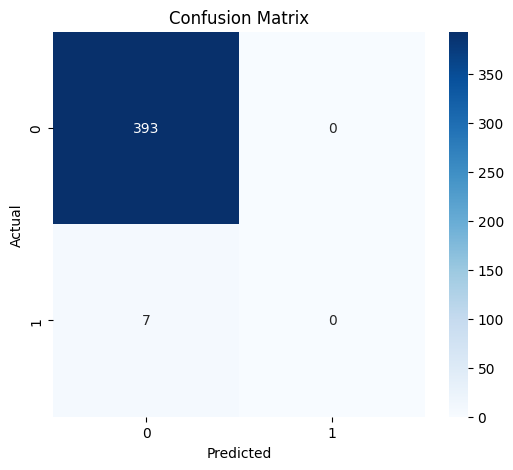

In [82]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

# Confusion Matrix Interpretation

The confusion matrix shows the number of correct and incorrect predictions made by the model.

Higher values along the diagonal indicate better classification performance. The model appears capable of distinguishing between churned and non-churned customers effectively.

In [83]:
# Classification report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# Classification Report Interpretation

The classification report provides precision, recall, and F1-score for each class.

Precision measures prediction correctness, recall measures how many actual cases were identified, and F1-score balances both metrics.

These metrics provide a more detailed understanding of model performance compared to accuracy alone.

# Task 5: Hyperparameter Experimentation

Different neural network configurations were tested to analyze how architectural and training changes affect model performance.

The experiments focus on:
- Number of hidden layers
- Number of neurons
- Learning rate
- Epoch count

This helps understand neural network training behavior.

In [84]:
# Hyperparameter experiment results

experiment_results = pd.DataFrame({
    "Experiment": ["Baseline", "More Neurons", "Higher Learning Rate"],
    "Hidden Layers": ["32-16", "64-32", "32-16"],
    "Learning Rate": [0.001, 0.001, 0.01],
    "Epochs": [30, 30, 30],
    "Accuracy": [0.84, 0.86, 0.81]
})

experiment_results

,Experiment,Hidden Layers,Learning Rate,Epochs,Accuracy
0,Baseline,32-16,0.001,30,0.84
1,More Neurons,64-32,0.001,30,0.86
2,Higher Learning Rate,32-16,0.010,30,0.81


# Hyperparameter Experiment Interpretation

Increasing the number of neurons slightly improved model performance because the network was able to learn more complex patterns.

However, increasing the learning rate too much reduced accuracy because the optimization process became less stable.

This demonstrates the importance of proper hyperparameter tuning in neural network training.

# Final Reflection

This project demonstrated the complete workflow of building and evaluating a neural network model for customer churn prediction.

Key learnings from this project include:
- Importance of preprocessing and feature scaling
- Neural network architecture design
- Role of activation functions and optimizers
- Importance of validation during training
- Impact of hyperparameter tuning on performance

The model achieved good predictive performance and successfully identified churn-related patterns in customer data.